### IMPORT

In [1]:
import json
import logging
import os
import random
import sys
from pathlib import Path

# --- ML & Data Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.optim as optim
import torchvision
import wandb
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader

# --- Configuration & Setup ---
import hydra
import rootutils
from omegaconf import DictConfig, OmegaConf
from hydra.core.global_hydra import GlobalHydra
GlobalHydra.instance().clear()

In [2]:
rootutils.setup_root(Path(".").resolve(), indicator=".project-root", pythonpath=True)
sys.path.append(str(Path(".").resolve().parent / "src"))

from bev.models.bevqa import get_model
from bev.data.bevqa_dataset import BEVQADataset
from bev.training.train import train_epoch, val_epoch
from bev.utils.text_utils import decode_question
from bev.models.head import OutputHead
from bev.models.mca import MCALayer


log = logging.getLogger(__name__)

with hydra.initialize(version_base=None, config_path="../configs"):
    
    cfg = hydra.compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

run_name: ${hydra:runtime.choices.paths}
training:
  batch_size: 4
  lr: 0.0001
  num_epochs: 50
  num_workers: 2
  early_stopping_patience: 5
  scheduler_patience: 3
  scheduler_factor: 0.5
  gradient_clip: 1.0
  use_amp: true
model:
  type: linear
paths:
  root_dir: ${hydra:runtime.cwd}
  data_dir: ${paths.root_dir}/data
  dataset_dir: /media/robesafe-sandra/Datos1/dataset_mini
  dict_dir: ${paths.dataset_dir}/dict_mini
  bev_features_dir: ${paths.dataset_dir}/bev_features_mini
  glove_path: ${paths.root_dir}/glove.6B/glove.6B.300d.txt
  output_dir: ${paths.root_dir}/outputs



In [3]:
run_name = "run_linear_mini"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
feat_dir = Path("/media/robesafe-sandra/Datos1/dataset_mini/bev_features_mini")
dict_dir = Path("/media/robesafe-sandra/Datos1/dataset_mini/dict_mini")
glove_path = Path("../glove.6B/glove.6B.300d.txt")

### DATASET

In [5]:
#TRAIN
bev_dir = feat_dir / "train"
json_path = dict_dir / "NuScenes_train_questions.json"
glove = glove_path
with open(json_path, "r") as f:
            data = json.load(f)
# Ottimizzazione: check esistenza file una volta sola
existing_files = {f.stem for f in bev_dir.glob("*.pt")}

In [6]:
import numpy as np
import torch
import json
import re 

def load_glove(glove_path):
    """
    Carica GloVe in modo efficiente:
    - Una matrice numpy (float32) per i vettori
    - Un dizionario word -> index
    - Aggiunge i token speciali <PAD> e <UNK>
    """
    words = []
    vectors = []

    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            if len(values) < 301: # check minimo per 300d
                continue
            word = values[0]
            vector = np.array(values[1:], dtype=np.float32)
            words.append(word)
            vectors.append(vector)

    # Aggiunta token speciali
    dim = vectors[0].shape[0] if vectors else 300
    pad_vector = np.zeros(dim, dtype=np.float32)
    unk_vector = np.random.normal(scale=0.6, size=(dim,)).astype(np.float32)

    words = ["<PAD>", "<UNK>"] + words
    vectors = [pad_vector, unk_vector] + vectors

    word2idx = {word: idx for idx, word in enumerate(words)}
    vectors = np.array(vectors, dtype=np.float32)
    return vectors, word2idx

glove_vectors, word2idx = load_glove(glove)

load_glove prende in ingresso glove
a quel punto lo divide in vectors e word2idx.

-vectors (400002,300)
Sono gli embeddings di 400K parole ciascuno esperesso da un vettore di 300.
Il primo vettore è pad (nullo) e il secondo è unknown (random per gli sconosciuti)

-word2idx è un dizionario che mappa tutte le 400K parole ad un indice numerico.

In [7]:
glove_vectors.shape

(400002, 300)

In [8]:
len(word2idx.keys())

400002

In [9]:
# Convertiamo in tensor e mettiamo in shared memory
glove_vectors = torch.from_numpy(glove_vectors).share_memory_()

In [10]:
def decode_question(data):
    """
    Ottiene mapping risposte dal dizionario già caricato.
    Aggiunge una classe fittizia <UNK_ANS> all'indice 0.
    """
    unique_answers = sorted(set(q["answer"] for q in data["questions"]))
    unique_answers = ["<UNK_ANS>"] + unique_answers
    
    answer2idx = {ans: idx for idx, ans in enumerate(unique_answers)}
    idx2answer = {idx: ans for ans, idx in answer2idx.items()}
    return answer2idx, idx2answer

answer2idx, idx2answer = decode_question(data)

Ottengo i dizionari risposte-idx e idx-risposte

In [11]:
answer2idx

{'<UNK_ANS>': 0,
 '0': 1,
 '1': 2,
 '10': 3,
 '2': 4,
 '3': 5,
 '4': 6,
 '5': 7,
 '6': 8,
 '7': 9,
 '8': 10,
 '9': 11,
 'barrier': 12,
 'bicycle': 13,
 'bus': 14,
 'car': 15,
 'construction vehicle': 16,
 'motorcycle': 17,
 'moving': 18,
 'no': 19,
 'not standing': 20,
 'parked': 21,
 'pedestrian': 22,
 'standing': 23,
 'stopped': 24,
 'traffic cone': 25,
 'trailer': 26,
 'truck': 27,
 'with rider': 28,
 'without rider': 29,
 'yes': 30}

In [12]:
idx2answer

{0: '<UNK_ANS>',
 1: '0',
 2: '1',
 3: '10',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: 'barrier',
 13: 'bicycle',
 14: 'bus',
 15: 'car',
 16: 'construction vehicle',
 17: 'motorcycle',
 18: 'moving',
 19: 'no',
 20: 'not standing',
 21: 'parked',
 22: 'pedestrian',
 23: 'standing',
 24: 'stopped',
 25: 'traffic cone',
 26: 'trailer',
 27: 'truck',
 28: 'with rider',
 29: 'without rider',
 30: 'yes'}

In [13]:
def encode_question(question, glove_vectors, word2idx, max_len=30):
    """
    Codifica la domanda usando i vettori GloVe pre-caricati.
    """
    clean_question = re.sub(r'[^\w\s]', ' ', question)
    tokens = clean_question.lower().split()

    dim = glove_vectors.shape[1]
    res = torch.zeros((max_len, dim), dtype=torch.float32)

    unk_idx = word2idx.get("<UNK>", 1)

    for i, token in enumerate(tokens[:max_len]):
        idx = word2idx.get(token, unk_idx)
        res[i] = glove_vectors[idx]

    return res

# Pre-calcolo in RAM di embeddings e indici risposte (I/O Bottleneck fix)
# Inizializzo samples, scorro tutte le domande:
# - salvo il token
# - se il token esiste in existing files lo encodo sennò vado avanti
# - encodare una domanda si intende codificarla (tolgo i simboli, splitto e lowero, restituisco la domanda codificata ovvero una serie di indici corrispondenti alle parole)
# - creo quindi un sample contenente (token, question, answer, question codificata, answer idx)
samples = []
for q in data["questions"]:
    token = q["sample_token"]
    if token in existing_files:
        # Pre-calcolo embedding domanda
        question_enc = encode_question(q["question"], glove_vectors, word2idx)
        # Pre-calcolo indice risposta (usa 0 <UNK_ANS> se non trovata)
        answer_idx = answer2idx.get(q["answer"], 0)
        
        # Salviamo sia i dati originali (per analisi) che quelli pre-calcolati
        samples.append({
            "token": token,
            "question": q["question"],
            "answer": q["answer"],
            "question_enc": question_enc,
            "answer_idx": torch.tensor(answer_idx, dtype=torch.long)
        })

In [33]:
#Esempio
print(f"{samples[0]}\n")

print(f"Ogni sample ha un token: {samples[0]["token"]}\n")
print(f"Ogni sample ha una domanda: {samples[0]["question"]}\n")
print(f"Ogni sample ha una risposta: {samples[0]["answer"]}\n")
print(f"Ogni sample ha un vettore di embedding delle parole della domanda: {samples[0]["question_enc"]}\n")
print(f"Infatti ad esempio questa domanda ha le seguenti parole: {re.sub(r'[^\w\s]', ' ', samples[0]["question"]).lower().split()}\n")
print(f"Numero parole: {len(re.sub(r'[^\w\s]', ' ', samples[0]["question"]).lower().split())}\n")
print("Puoi vedere come solo i primi 8 vettori sono non nulli")
print(f"{samples[0]["question_enc"][0]}\n")
print(f"{samples[0]["question_enc"][1]}\n")
print(f"{samples[0]["question_enc"][2]}\n")
print(f"{samples[0]["question_enc"][3]}\n")
print(f"{samples[0]["question_enc"][4]}\n")
print(f"{samples[0]["question_enc"][5]}\n")
print(f"{samples[0]["question_enc"][6]}\n")
print(f"{samples[0]["question_enc"][7]}\n")
print(f"{samples[0]["question_enc"][8]}\n")
print(f"Ogni sample ha una risposta codificata: {samples[0]["answer_idx"]}\n")

{'token': 'ca9a282c9e77460f8360f564131a8af5', 'question': 'There is a parked thing; what is it?', 'answer': 'truck', 'question_enc': tensor([[-0.4762,  0.0695, -0.0131,  ..., -0.0502, -0.0759,  0.1486],
        [-0.1749,  0.2296,  0.2492,  ..., -0.2413, -0.4040,  0.0547],
        [-0.2971,  0.0940, -0.0967,  ...,  0.0597, -0.2285,  0.2960],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]), 'answer_idx': tensor(27)}

Ogni sample ha un token: ca9a282c9e77460f8360f564131a8af5

Ogni sample ha una domanda: There is a parked thing; what is it?

Ogni sample ha una risposta: truck

Ogni sample ha un vettore di embedding delle parole della domanda: tensor([[-0.4762,  0.0695, -0.0131,  ..., -0.0502, -0.0759,  0.1486],
        [-0.1749,  0.2296,  0.2492,  ..., -0.2413, -0.4040,  0.0547],
        [-0.2971,  0.0940, -0.0967,  

In [34]:
# IL DATASET PERÒ È COMPOSTO SOLO DA:
# - features
# - question_enc
# - answer

sample = samples[5]
token = sample["token"]

# Carica solo le features spaziali dal disco
features = torch.load(bev_dir / f"{token}.pt", map_location="cpu", weights_only=True)
features = (
    features["features_fused"].squeeze(0).to(torch.float32)
)  # [1,128,200,200] → [128,200,200]

In [35]:
print(f"Features: {features}\n")
print(f"Question encoded: {sample["question_enc"]}\n")
print(f"Answer idx: {sample["answer_idx"]}\n")

Features: tensor([[[ 1.2910,  2.4785,  2.4785,  ...,  2.4785,  2.4785,  1.5645],
         [ 0.5093, -0.1227, -0.1227,  ..., -0.1227, -0.1227,  1.5107],
         [ 0.5093, -0.1227, -0.1227,  ..., -0.1227, -0.1227,  1.5107],
         ...,
         [ 0.5093, -0.1227, -0.1227,  ..., -0.1227, -0.1227,  1.5107],
         [ 0.5093, -0.1227, -0.1227,  ..., -0.1227, -0.1227,  1.5107],
         [-0.7681, -0.2722, -0.2722,  ..., -0.2722, -0.2722, -0.9619]],

        [[-1.4180, -0.3145, -0.3145,  ..., -0.3145, -0.3145,  1.0439],
         [-0.1122,  0.1284,  0.1284,  ...,  0.1284,  0.1284, -0.7598],
         [-0.1122,  0.1284,  0.1284,  ...,  0.1284,  0.1284, -0.7598],
         ...,
         [-0.1122,  0.1284,  0.1284,  ...,  0.1284,  0.1284, -0.7598],
         [-0.1122,  0.1284,  0.1284,  ...,  0.1284,  0.1284, -0.7598],
         [-0.1641,  0.2766,  0.2766,  ...,  0.2766,  0.2766, -1.6738]],

        [[-2.5000, -1.5801, -1.5801,  ..., -1.5801, -1.5801, -0.0668],
         [-0.7915,  0.3191,  0.3191

In [ ]:
train_dataset = BEVQADataset(
    bev_dir=feat_dir / "train",
    json_path=dict_dir / "NuScenes_train_questions.json",
    glove=glove_path,
    answer2idx=None # Il train crea il mapping
)

In [ ]:
val_dataset = BEVQADataset(
    bev_dir=feat_dir / "val",
    json_path=dict_dir / "NuScenes_val_questions.json",
    glove=glove_path,
    answer2idx=train_dataset.answer2idx # Il val usa lo stesso mapping del train
)

In [37]:
feat, quest, ans = train_dataset[6]
print(feat.shape, quest.shape, ans)

torch.Size([128, 200, 200]) torch.Size([30, 300]) tensor(21)


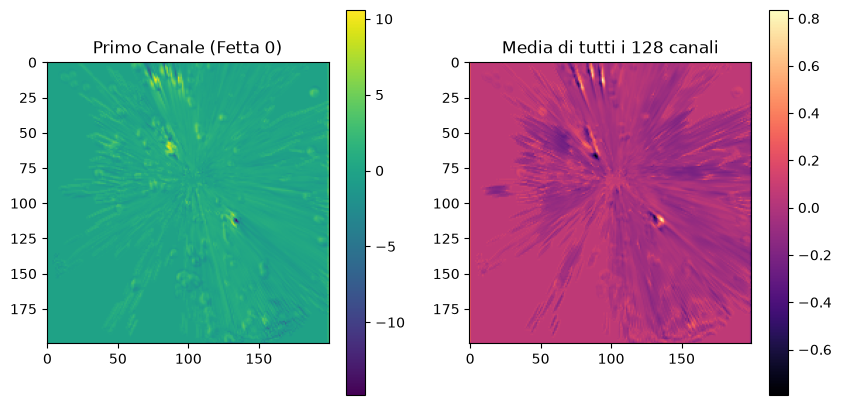

In [38]:
import matplotlib.pyplot as plt
import torch

# Convertiamo in numpy (staccando dal gradiente se necessario)
feat_np = feat.detach().cpu().numpy()

plt.figure(figsize=(10, 5))

# Opzione A: Visualizza il primo canale (indice 0)
plt.subplot(1, 2, 1)
plt.imshow(feat_np[0], cmap='viridis')
plt.title("Primo Canale (Fetta 0)")
plt.colorbar()

# Opzione B: Visualizza la media di tutti i 128 canali
plt.subplot(1, 2, 2)
plt.imshow(feat_np.mean(axis=0), cmap='magma')
plt.title("Media di tutti i 128 canali")
plt.colorbar()

plt.show()

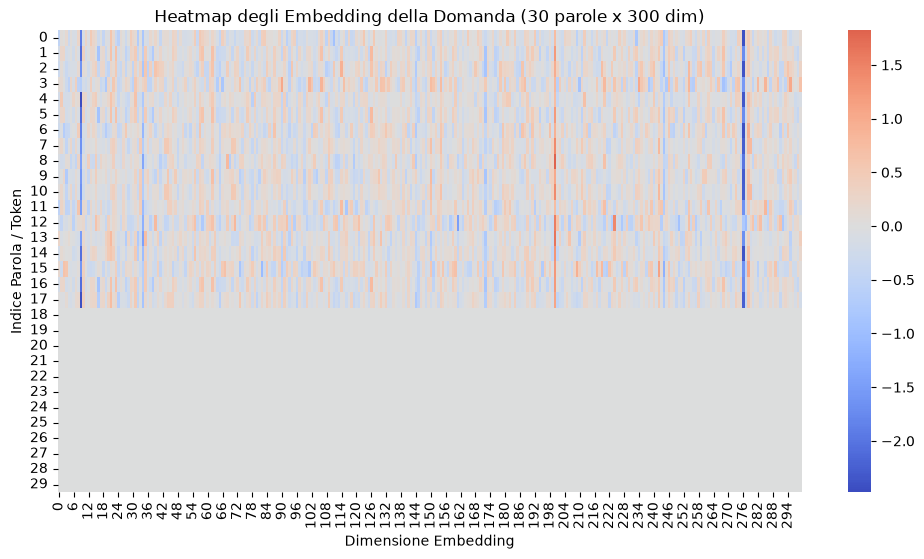

In [39]:
import seaborn as sns

quest_np = quest.detach().cpu().numpy()

plt.figure(figsize=(12, 6))
# Usiamo seaborn per una heatmap pulita
sns.heatmap(quest_np, cmap='coolwarm', center=0)
plt.title("Heatmap degli Embedding della Domanda (30 parole x 300 dim)")
plt.xlabel("Dimensione Embedding")
plt.ylabel("Indice Parola / Token")
plt.show()

In [22]:
print(ans.item())

19


In [23]:
print(idx2answer[ans.item()])

no


### DATALOADER

In [24]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True) # False solo per fare debug così il primo di dataset è anche il primo di dataloader
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [25]:
feat, quest, ans = next(iter(train_dataloader))
print(feat.shape, quest.shape, ans)

torch.Size([4, 128, 200, 200]) torch.Size([4, 30, 300]) tensor([19,  5, 30, 23])
